In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Build Autoencoder

In [ ]:
# 1. LOAD DATA
df = pd.read_csv('/content/ai4i_engineered_features.csv')

# 2. FEATURE ENGINEERING
df['temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['stress_index'] = df['Torque [Nm]'] / (df['Rotational speed [rpm]'] + 1e-5)
df['torque_wear'] = df['Torque [Nm]'] * df['Tool wear [min]']

# Select Features & Target
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]', 'temp_diff', 'stress_index', 'torque_wear']
target = 'Machine failure'

X = df[features]
y = df[target]

# 3. CHRONOLOGICAL SPLIT (70% Train, 15% Val, 15% Test)
n = len(X)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

X_train_raw, y_train = X[:train_end], y[:train_end]
X_val_raw, y_val = X[train_end:val_end], y[train_end:val_end]
X_test_raw, y_test = X[val_end:], y[val_end:]

# 4. SCALING (Fit only on Training data to avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# 5. FILTER FOR NORMAL DATA (Autoencoders learn 'Normal' behavior)
# We train and validate only on samples where Machine failure == 0
X_train_normal = X_train[y_train == 0]
X_val_normal = X_val[y_val == 0]

# 6. BUILD THE AUTOENCODER
input_dim = X_train.shape[1]

autoencoder = models.Sequential([
    # Encoder
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'), # Bottleneck

    # Decoder
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear') # Output matches input size
])

autoencoder.compile(optimizer='adam', loss='mse')

# 7. TRAIN
# Input and Output are BOTH the normal data (Self-supervised)
# We use the separate validation set created in the split
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_normal, X_val_normal),
    verbose=1
)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7677 - val_loss: 1.1801
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4997 - val_loss: 0.7939
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3263 - val_loss: 0.5914
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2343 - val_loss: 0.4177
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1825 - val_loss: 0.3382
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1480 - val_loss: 0.3092
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1286 - val_loss: 0.2858
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1190 - val_loss: 0.2881
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1058 - val_loss: 0.2655
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0962 - val_loss: 0.2542
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0901 - val_loss: 0.2519
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Train ONLY on Normal Data

Original Training Shape: (7000, 8)
Filtered (Normal Only) Training Shape: (6722, 8)
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8694 - val_loss: 0.5134
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5741 - val_loss: 0.4254
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4817 - val_loss: 0.4046
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4094 - val_loss: 0.3361
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3363 - val_loss: 0.3152
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2820 - val_loss: 0.3025
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2427 - val_loss: 0.2972
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2111 - val_loss: 0.3037
Epoch 9/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1827 - val_loss: 0.2819
Epoch 10/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1599 - val_loss: 0.2710
Epoch 11/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1396 - val_loss: 0.2446
Epoch 12/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.

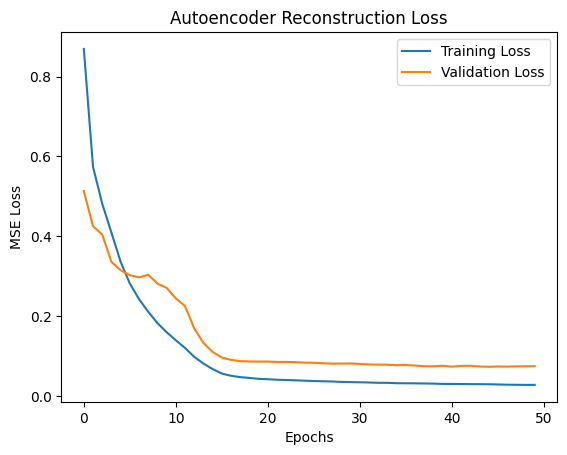

In [ ]:
# --- 1. Filter for Normal Samples ---
# We use the y_train we created in the previous step to mask the features
# Only '0' (no failure) samples are used to teach the model 'Normal' behavior
X_train_normal = X_train[y_train == 0]

print(f"Original Training Shape: {X_train.shape}")
print(f"Filtered (Normal Only) Training Shape: {X_train_normal.shape}")

# --- 2. Define the Autoencoder Architecture ---
input_dim = X_train_normal.shape[1]

autoencoder = models.Sequential([
    # Encoder: Compress features into a bottleneck
    layers.Dense(16, activation='relu', input_shape=(input_dim,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu', name="bottleneck"), # Latent Space

    # Decoder: Reconstruct features back to original dimension
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

# --- 3. Train the Model ---
# Notice: we pass X_train_normal as both the features (X) and the targets (y)
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=50,
    batch_size=32,
    validation_split=0.15, # Using 15% of the normal data for validation
    shuffle=True,          # Shuffle normal data so the model doesn't learn sequence order
    verbose=1
)

# --- 4. Plot Training History ---
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Reconstruction Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## Anomaly Detection Threshold

The autoencoder was trained on normal operating data to learn its underlying patterns. Reconstruction error was used as an anomaly score.

A threshold was defined using the 95th percentile of reconstruction error on training data. Any instance with error above this threshold was classified as anomalous.

This approach allows the model to identify deviations from normal behavior without requiring labeled failure data.

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 760us/step
Calculated Anomaly Threshold: 1.4799

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1471
           1       0.00      0.00      0.00        29

    accuracy                           0.98      1500
   macro avg       0.49      0.50      0.49      1500
weighted avg       0.96      0.98      0.97      1500



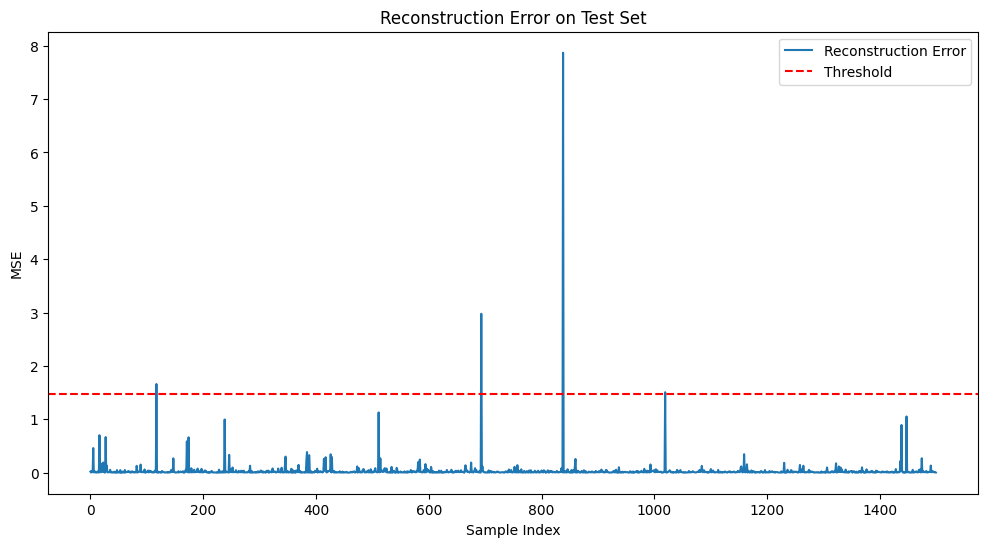

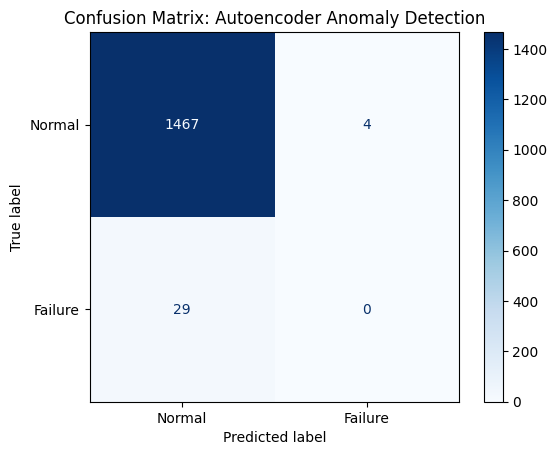

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# 1. Calculate Reconstruction Error (MSE) for Test Set
# autoencoder.predict returns the reconstructed version of X_test
X_test_pred = autoencoder.predict(X_test)
mse_test = np.mean(np.power(X_test - X_test_pred, 2), axis=1)

# 2. Set Threshold using Training Error
# We calculate error on X_train_normal to see what "good" reconstruction looks like
X_train_pred = autoencoder.predict(X_train_normal)
mse_train = np.mean(np.power(X_train_normal - X_train_pred, 2), axis=1)

threshold = np.mean(mse_train) + 2 * np.std(mse_train)
print(f"Calculated Anomaly Threshold: {threshold:.4f}")

# 3. Classify Anomalies
# If MSE > Threshold, it's an anomaly (1), otherwise normal (0)
y_pred = [1 if e > threshold else 0 for e in mse_test]

# 4. Evaluation and Visualization
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plotting the Reconstruction Error vs Threshold
plt.figure(figsize=(12, 6))
plt.plot(mse_test, label='Reconstruction Error')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Reconstruction Error on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('MSE')
plt.legend()
plt.show()

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Failure'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Autoencoder Anomaly Detection')
plt.show()

In [ ]:
def build_lstm_with_attention(input_shape):
    # 1. Input Layer (Sequence Length, Number of Features)
    inputs = layers.Input(shape=input_shape)

    # 2. LSTM Layer
    # return_sequences=True is REQUIRED to pass data to an Attention layer
    lstm_out = layers.LSTM(64, return_sequences=True)(inputs)
    lstm_out = layers.Dropout(0.2)(lstm_out)

    # 3. Simple Attention Mechanism
    # We calculate a weight for each time step
    attention = layers.Dense(1, activation='tanh')(lstm_out)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(64)(attention)
    attention = layers.Permute([2, 1])(attention)

    # Multiply the LSTM output by the attention weights
    sent_representation = layers.Multiply()([lstm_out, attention])
    sent_representation = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(sent_representation)

    # 4. Fully Connected Layers
    x = layers.Dense(32, activation='relu')(sent_representation)
    x = layers.Dropout(0.2)(x)

    # 5. Output Layer (Binary Classification)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    # Compile
    model = models.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
    )

    return model

# --- Usage ---
# Assuming X_train_seq shape is (9990, 10, num_features)
sequence_length = 10
num_features = X_train.shape[1] # Using the number of features from your scaling step

model = build_lstm_with_attention((sequence_length, num_features))
model.summary()

# --- Training ---
# history = model.fit(
#     X_train_seq, y_train_seq,
#     epochs=30,
#     batch_size=64,
#     validation_split=0.2,
#     class_weight={0: 1, 1: 10} # Handling the class imbalance (Failure is rare)
# )

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 10, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 10, 64)    │     18,688 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 10, 1)     │         65 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 10)        │          0 │ dense_25[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10)        │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 64, 10)    │          0 │ activation_1[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 10, 64)    │          0 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 10, 64)    │          0 │ dropout_2[0][0],  │
│ (Multiply)          │                   │            │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 64)        │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 32)        │      2,080 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 1)         │         33 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,866 (81.51 KB)

 Trainable params: 20,866 (81.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def create_sequences(X, y, time_steps=10):
    """
    Converts 2D tabular data into 3D sequences for LSTM.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Create sequences for all three sets
X_train_seq, y_train_seq = create_sequences(X_train, y_train.values, time_steps=10)
X_val_seq, y_val_seq = create_sequences(X_val, y_val.values, time_steps=10)
X_test_seq, y_test_seq = create_sequences(X_test, y_test.values, time_steps=10)

print(f"Train sequence shape: {X_train_seq.shape}")
print(f"Val sequence shape:   {X_val_seq.shape}")
print(f"Test sequence shape:  {X_test_seq.shape}")

Train sequence shape: (6990, 10, 8)
Val sequence shape:   (1490, 10, 8)
Test sequence shape:  (1490, 10, 8)


In [ ]:
# Save the 3D feature sequences
# Save 3D feature sequences
np.save('X_train.npy', X_train_seq)
np.save('X_val.npy', X_val_seq)
np.save('X_test.npy', X_test_seq)

# Save 1D labels
np.save('y_train.npy', y_train_seq)
np.save('y_val.npy', y_val_seq)
np.save('y_test.npy', y_test_seq)

print("Sequence data saved successfully as .npy files.")

print("Sequence data saved successfully as .npy files.")

Sequence data saved successfully as .npy files.
Sequence data saved successfully as .npy files.


In [19]:
np.save('/content/drive/My Drive/X_train.npy', X_train_seq)
np.save('/content/drive/My Drive/X_train.npy', X_val_seq)
np.save('/content/drive/My Drive/X_train.npy', X_test_seq)
np.save('/content/drive/My Drive/X_train.npy', y_train_seq)
np.save('/content/drive/My Drive/X_train.npy', y_val_seq)
np.save('/content/drive/My Drive/X_train.npy', y_train_seq)